In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
flights = sns.load_dataset('flights')
flights.groupby('year')['month'].count()

year
1949    12
1950    12
1951    12
1952    12
1953    12
1954    12
1955    12
1956    12
1957    12
1958    12
1959    12
1960    12
Name: month, dtype: int64

In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [25]:
# year + month - >datetime
flights['date'] =  flights['year'].astype(str) + '-' + flights['month'].astype(str) + '-01'
flights['date'] = pd.to_datetime(flights['date'])
flights = flights.sort_values(by='date').reset_index(drop=True)
flights['date']

0     1949-01-01
1     1949-02-01
2     1949-03-01
3     1949-04-01
4     1949-05-01
         ...    
139   1960-08-01
140   1960-09-01
141   1960-10-01
142   1960-11-01
143   1960-12-01
Name: date, Length: 144, dtype: datetime64[ns]

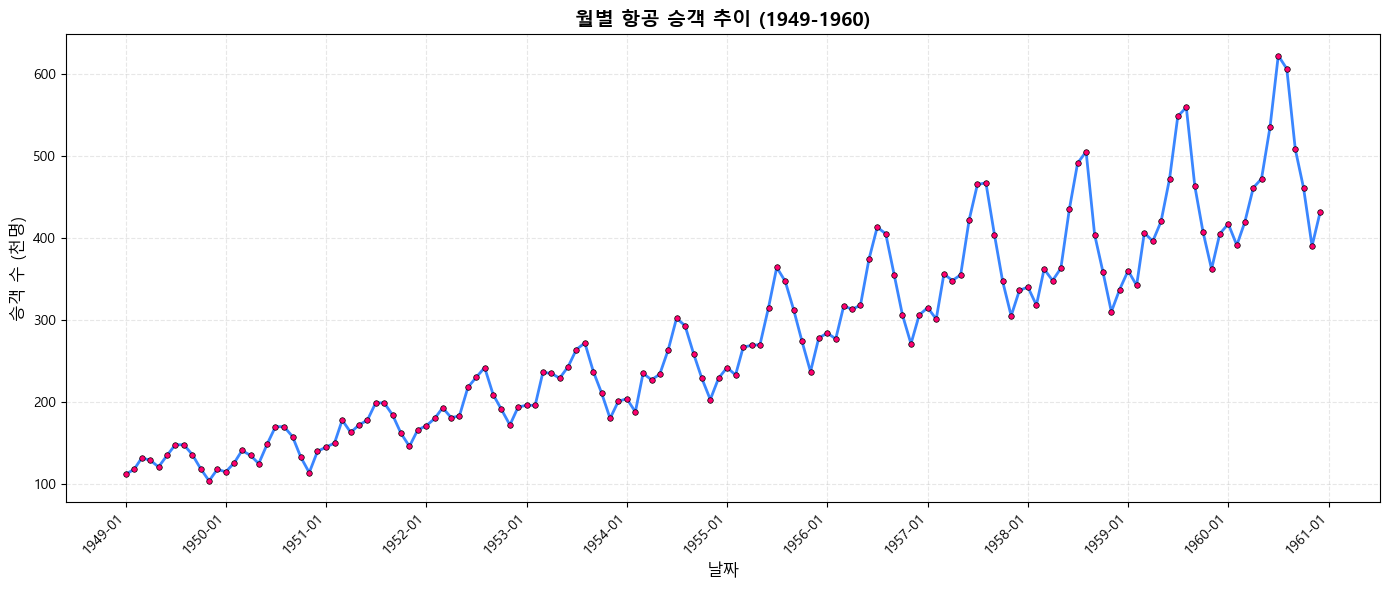

In [26]:
# 항공 승객수는 어떻게 변화했는지?
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(flights['date'], flights['passengers'], 
        linewidth=2, color='#3A86FF', marker='o', markersize=4,
        markerfacecolor='#FF006E', markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('승객 수 (천명)', fontsize=12)
ax.set_title('월별 항공 승객 추이 (1949-1960)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# X축 날짜 포맷팅
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# 어느달의 승객이 가장 많은가?
